In [1]:
import numpy as np, matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib
import corner
import pickle
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

import BaryonForge as bfg
import pyccl as ccl
from scipy.integrate import cumulative_trapezoid, simpson
from astropy import constants as con
import os

os.environ["PK_MODEL"] = "BCEmu7"
os.environ["METHOD"] = "exact"
os.environ["N_FRB"]    = "100"
os.environ["N_PARAMS"] = "1"
from mcmc_funcs import *

import sys
sys.path.append(os.path.abspath('.'))

from scipy.stats import lognorm
from scipy.signal import fftconvolve

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams.update(
    {
        'text.usetex': False,
        'font.family': 'stixgeneral',
        'mathtext.fontset': 'stix',
    }
)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['image.origin'] = 'lower'
sns.set_context('talk') 
sns.set(font_scale=2)
sns.set_palette('colorblind')
sns.set_style('ticks')
plt.rcParams['font.family'] = 'Times New Roman'

N = 10
cmap = plt.get_cmap("rainbow")
colors = [cmap(i) for i in np.linspace(0, 1, N)]

import matplotlib as mpl

mpl.rcParams['axes.linewidth'] = 2
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['ytick.major.width'] = 2
mpl.rcParams['xtick.minor.width'] = 1
mpl.rcParams['ytick.minor.width'] = 1

mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['xtick.minor.size'] = 5
mpl.rcParams['ytick.minor.size'] = 5

redshifts = np.linspace(0, 5, 1000)
from astropy.cosmology import Planck18 as cosmo

cmap = matplotlib.cm.get_cmap('RdPu')
colors = ["white"]+[cmap(i/100) for i in range(100)]

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", 
                                                           colors)


Not using emulators.
Unknown Pk_model!


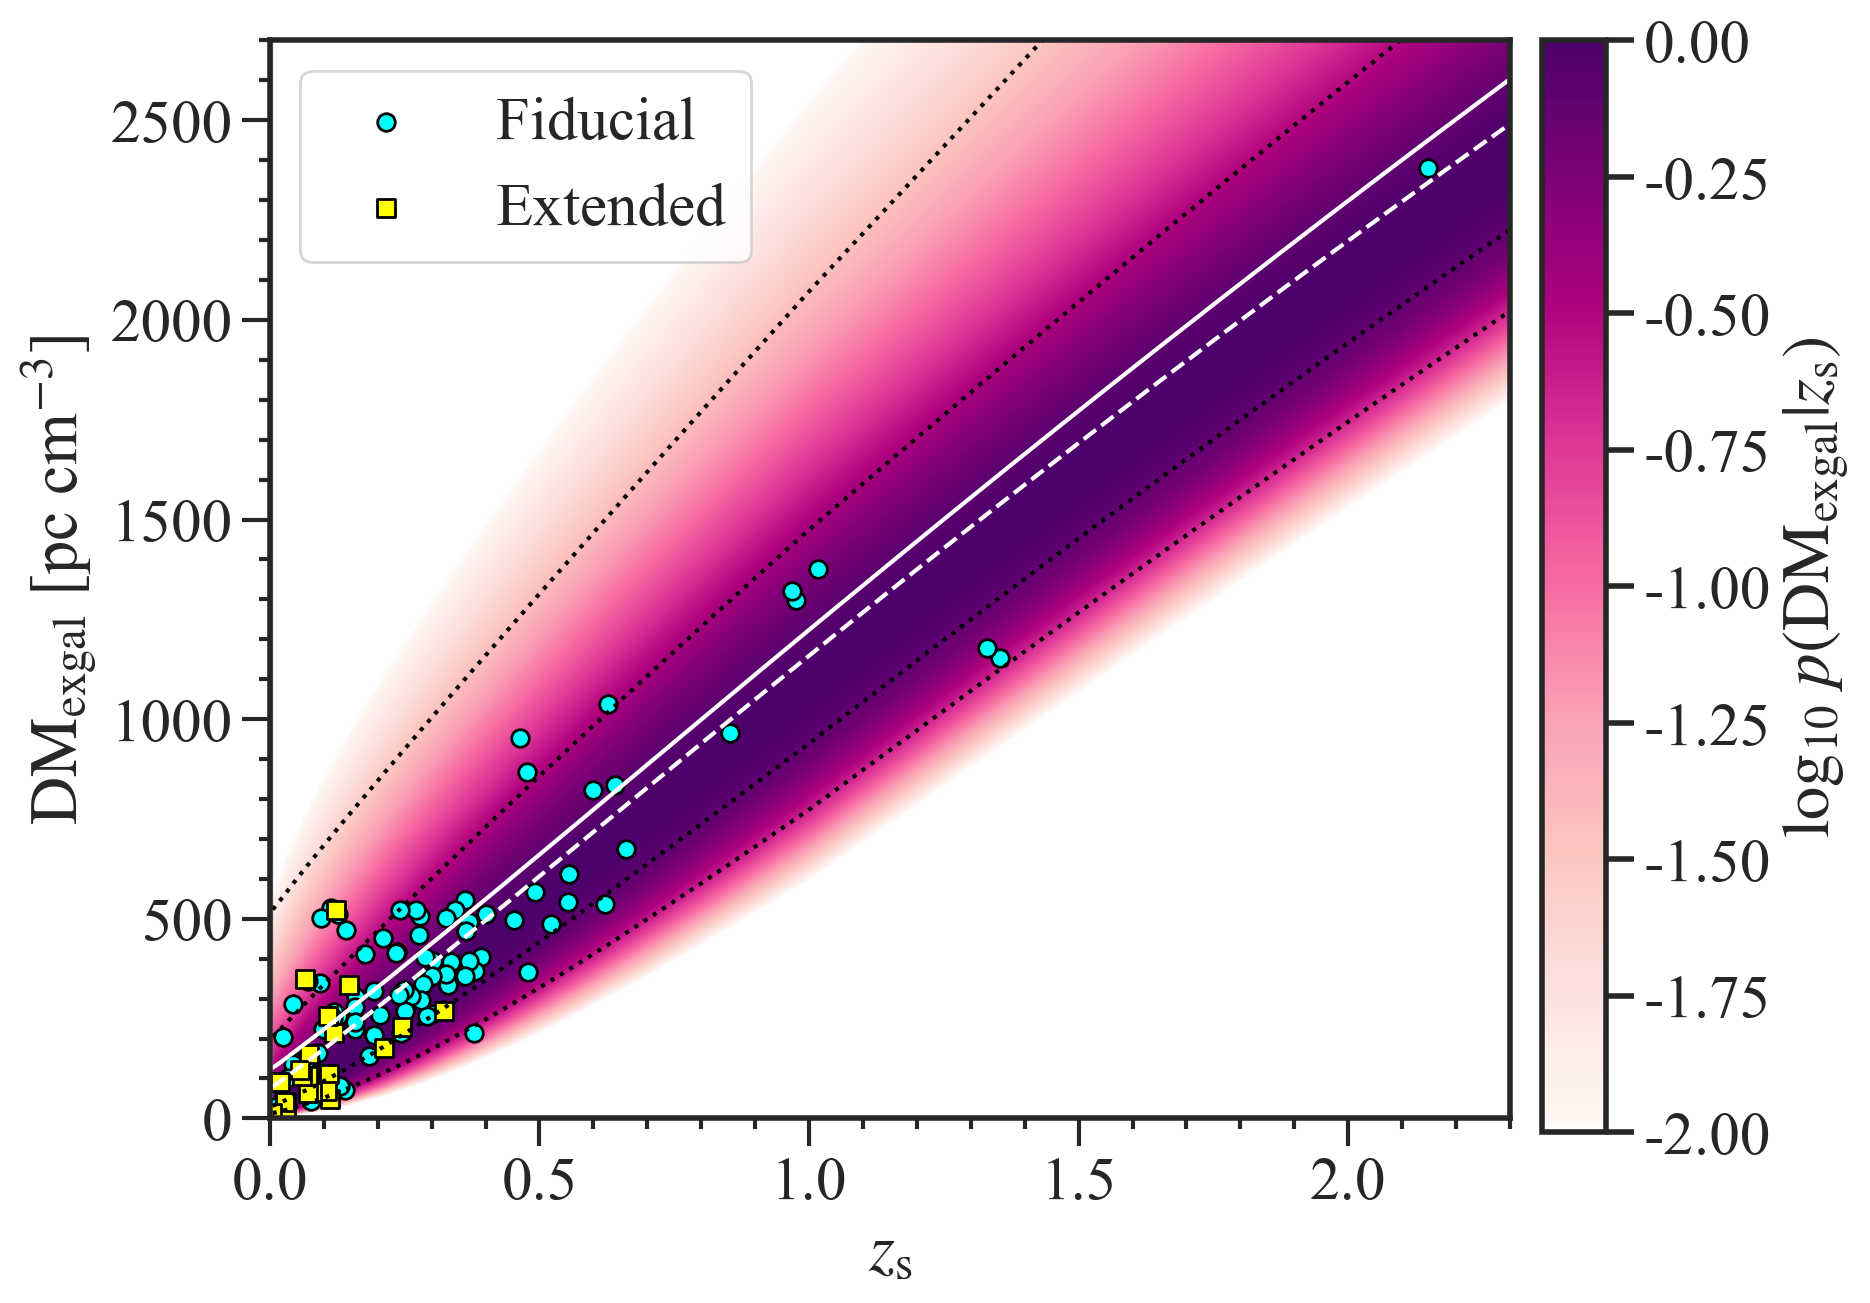

In [2]:
from scipy.interpolate import interp1d
def normalized_lognorm_pdf(x, mu, sigma):
    pdf = lognorm.pdf(x, s=sigma, scale=np.exp(mu))
    return pdf / np.trapz(pdf, x)


def compute_extragal_pdfs(redshifts, mu_cosmic, sigma_cosmic,
                          mu_host_rest, sigma_host_rest, DM_grid):
    pdf_list = []

    for z, mu_c, sig_c in zip(redshifts, mu_cosmic, sigma_cosmic):

        # Cosmic DM term
        pdf_cosmic = normalized_lognorm_pdf(DM_grid, mu_c, sig_c)

        # Host DM in observer frame
        DM_host_obs = DM_grid / (1 + z)
        pdf_host_rest = lognorm.pdf(DM_host_obs, s=sigma_host_rest, scale=np.exp(mu_host_rest))

        # Jacobian
        pdf_host_obs = (1 + z) * pdf_host_rest
        pdf_host_obs /= np.trapz(pdf_host_obs, DM_grid)

        # Convolution
        pdf = fftconvolve(pdf_cosmic, pdf_host_obs, mode="full")[:len(DM_grid)]
        pdf /= np.trapz(pdf, DM_grid)

        pdf_list.append(pdf)

    pdf_arr = np.array(pdf_list)
    pdf_arr = np.clip(pdf_arr, 1e-50, None)
    return pdf_arr


def plot_extragal_grid(ax, redshifts, DM_grid, pdf_array, frb_df, dmhalo,
                       title="Extragalactic DM", vmin=-2, vmax=0, plot_colorbar=False, label_y=False, real_frbs=False, single_plot=False, plot_percentiles=True):
    normed = pdf_array.T / pdf_array.T.max(axis=0)

    im = ax.imshow(
        np.log10(normed + 1e-300),
        origin='lower',
        aspect='auto',
        extent=[redshifts.min(), redshifts.max(), DM_grid.min(), DM_grid.max()],
        cmap=cmap,
        vmin=vmin, vmax=vmax
    )
    
    # Plot mean, median, 16th and 84th percentiles
    if plot_percentiles:
        # Ensure pdf_array is (n_DM, n_z)
        if pdf_array.shape[0] != len(DM_grid):
            pdf_array = pdf_array.T

        # Compute mean
        means = np.sum(pdf_array * DM_grid[:, np.newaxis], axis=0) / np.sum(pdf_array, axis=0)

        # Compute CDF along DM axis
        cdf = np.cumsum(pdf_array, axis=0)
        cdf /= cdf[-1, :]  # normalize to 1

        # Prepare arrays for percentiles
        p5 = np.zeros_like(redshifts)
        p16 = np.zeros_like(redshifts)
        median = np.zeros_like(redshifts)
        p84 = np.zeros_like(redshifts)
        p95 = np.zeros_like(redshifts)

        # Interpolate DM values at desired percentiles
        for i in range(len(redshifts)):
            f = interp1d(cdf[:, i], DM_grid, bounds_error=False, fill_value=(DM_grid[0], DM_grid[-1]))
            p5[i] = f(0.025)
            p16[i] = f(0.16)
            median[i] = f(0.5)
            p84[i] = f(0.84)
            p95[i] = f(0.975)

        # Plot curves
        ax.plot(redshifts, means, color='white', linestyle='-')
        ax.plot(redshifts, median, color='white', linestyle='--')
        ax.plot(redshifts, p16, color='black', linestyle=':')
        ax.plot(redshifts, p84, color='black', linestyle=':')
        ax.plot(redshifts, p5, color='black', linestyle=':')
        ax.plot(redshifts, p95, color='black', linestyle=':')
        ax.legend(loc='upper left')


    # FRB scatter
    if real_frbs and single_plot:
        frb_df_fiducial = frb_df[frb_df["sharma_sample"]=="yes"].reset_index()
        frb_df_extended = frb_df[frb_df["sharma_sample"]=="unclear"].reset_index()
        ax.scatter(
            frb_df_fiducial.z_sample,
            frb_df_fiducial.DMexgal - dmhalo,
            color="cyan", s=40, marker="o", edgecolors='black', label="Fiducial"
        )
        ax.scatter(
            frb_df_extended.z_sample,
            frb_df_extended.DMexgal - dmhalo,
            color="yellow", s=40, marker="s", edgecolors='black', label="Extended"
        )
        ax.legend(loc="upper left")
    elif real_frbs:
        frb_df_fiducial = frb_df[frb_df["sharma_sample"]=="yes"].reset_index()
        frb_df_extended = frb_df[frb_df["sharma_sample"]=="unclear"].reset_index()
        ax.scatter(
            frb_df_fiducial.z_sample,
            frb_df_fiducial.DMexgal - dmhalo,
            color="cyan", s=40, marker="o", edgecolors='black', label="Fiducial"
        )
        ax.scatter(
            frb_df_extended.z_sample,
            frb_df_extended.DMexgal - dmhalo,
            color="yellow", s=40, marker="s", edgecolors='black', label="Extended"
        )
        ax.set_title(title)
        ax.legend(loc="upper left")
    else:
        ax.scatter(
            frb_df.z_sample,
            frb_df.DMexgal - dmhalo,
            color="white", s=50, marker="D", edgecolors='black',
            label="Mock"
        )
        ax.set_title(title)
        ax.legend(loc="upper left")

    if plot_colorbar and single_plot:
        cax = fig.add_axes([0.92, 0.1, 0.04, 0.78])
        cb = fig.colorbar(im, cax=cax, label=r'$\log_{10}\, p(\mathrm{DM_{exgal}}|z_\mathrm{s})$')
    elif plot_colorbar:
        cax = fig.add_axes([0.92, 0.1, 0.02, 0.78])
        cb = fig.colorbar(im, cax=cax, label=r'$\log_{10}\, p(\mathrm{DM_{exgal}}|z_\mathrm{s})$')

    ax.set_xlabel(r'$z_\mathrm{s}$')
    if label_y:
        ax.set_ylabel(r'$\mathrm{DM_{exgal}}$ [pc cm$^{-3}$]')

    ax.set_xlim(redshifts.min(), 2.3)
    ax.set_ylim(0, 2700)

    ax.xaxis.set_major_locator(plt.MultipleLocator(0.5))
    ax.xaxis.set_minor_locator(plt.MultipleLocator(0.1))
    ax.yaxis.set_major_locator(plt.MultipleLocator(500))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(100))

    ax.tick_params(which='both', width=1.5)
    ax.tick_params(which='major', length=10)
    ax.tick_params(which='minor', length=4)

    return fig, ax

fig, ax = plt.subplots(1, 1, figsize=(8, 7), sharey=True)

DMhost_mean, DMhost_var = 120, 155
mu_host_rest = np.log(DMhost_mean**2 / np.sqrt(DMhost_mean**2 + DMhost_var**2))
sigma_host_rest = np.sqrt(np.log(1 + DMhost_var**2 / DMhost_mean**2))

frb_sample = pd.read_csv("data/frb_results/frb_sample.csv")

redshifts = np.linspace(0, 5, 1000)
DM_var = get_DM_variance(np.array([cosmo.H0.cgs.value]), np.array([cosmo.Ob0]), np.array([cosmo.Om0]), np.array([0.8111]),
                         np.array([{"log_Mc": 12.98, "theta_ej": 4.57, "eta_delta": 0.28, "delta": 7.36, 
                                    "mu_beta": 0.95, "gamma": 2.54, "eta": 0.25, "A": 0.055/2, "tau": -1.5}]), 
                         redshifts, "BCEmu")[0]

DM_mean = DM_cosmic_mean(np.array([cosmo.Om0]), np.array([cosmo.Ob0]), 
                         np.array([cosmo.H0.cgs.value]), np.array([0.8111]), 
                         np.array([{"log_Mc": 12.98, "theta_ej": 4.57, "eta_delta": 0.28, "delta": 7.36, 
                                    "mu_beta": 0.95, "gamma": 2.54, "eta": 0.25, "A": 0.055/2, "tau": -1.5}]),
                         "BCEmu",
                         redshifts)[0]

mu_cosmic = np.log(DM_mean**2 / np.sqrt(DM_mean**2 + DM_var**2))
sigma_cosmic = np.sqrt(np.log(1 + DM_var**2 / DM_mean**2))

DM_grid = np.linspace(0, 10000, 10000)
pdf = compute_extragal_pdfs(
    redshifts,
    mu_cosmic, sigma_cosmic,
    mu_host_rest, sigma_host_rest,
    DM_grid
)

dmhalo = 50
plot_extragal_grid(
    ax, redshifts, DM_grid, pdf,
    frb_sample,
    dmhalo,
    title="", real_frbs=True, plot_colorbar=True, label_y=True, single_plot=True
)

plt.savefig('figures/dmz.pdf', dpi=400, bbox_inches='tight')


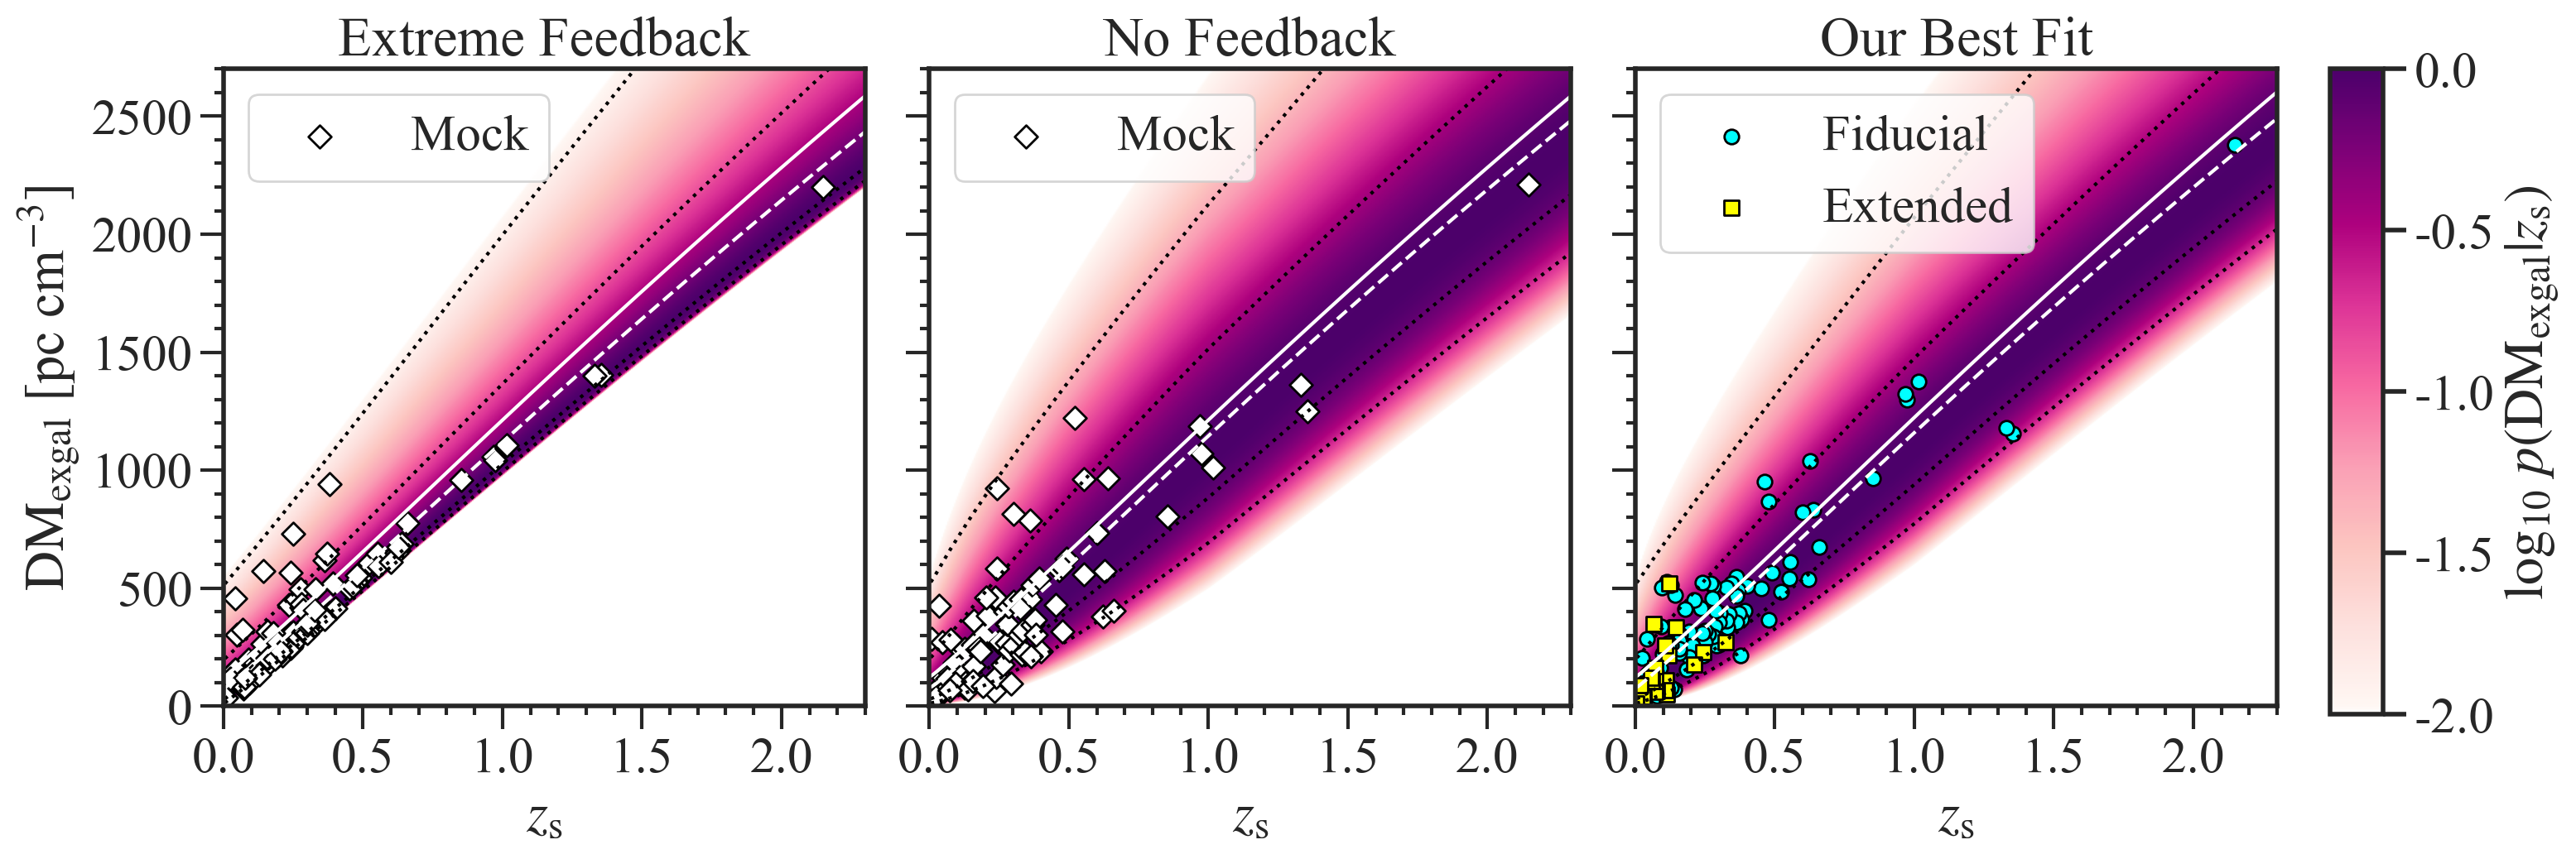

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
plt.subplots_adjust(wspace=0.1)


frb_sample_extremefeedback = pd.read_csv("data/frb_results/extreme_scenario_test/mock_frb_sample_extremefeedback.csv")
frb_sample_extremefeedback = frb_sample_extremefeedback[frb_sample_extremefeedback["sharma_sample"]=="yes"].reset_index()

DM_mean = DM_cosmic_mean(np.array([cosmo.Om0]), np.array([cosmo.Ob0]), np.array([cosmo.H0.cgs.value]), np.array([0.8111]),
                         np.array([{"log_Mc": 12.5, "theta_ej": 3.5, "eta_delta": 0.2, "delta": 7, 
                                    "mu_beta": 1, "gamma": 2.5, "eta": 0.2, "A": 0.055/2, "tau": -1.5}]), 
                         "BCEmu",
                         redshifts)[0]

DM_var_ef = np.ones(np.shape(DM_mean))

# Lognormal parameters for cosmic term
mu_cosmic_extreme = np.log(DM_mean**2 / np.sqrt(DM_mean**2 + DM_var_ef**2))
sigma_cosmic_extreme = np.sqrt(np.log(1 + DM_var_ef**2 / DM_mean**2))

# Host galaxy distribution in *rest frame*
DMhost_mean, DMhost_var = 120, 155
mu_host_rest = np.log(DMhost_mean**2 / np.sqrt(DMhost_mean**2 + DMhost_var**2))
sigma_host_rest = np.sqrt(np.log(1 + DMhost_var**2 / DMhost_mean**2))

pdf_extreme = compute_extragal_pdfs(
    redshifts,
    mu_cosmic_extreme, sigma_cosmic_extreme,
    mu_host_rest, sigma_host_rest,
    DM_grid
)

plot_extragal_grid(
    axes[0], redshifts, DM_grid, pdf_extreme,
    frb_sample_extremefeedback,
    dmhalo,
    title="Extreme Feedback", 
    label_y=True
)


frb_sample_nofeedback = pd.read_csv("data/frb_results/extreme_scenario_test/mock_frb_sample_nofeedback.csv")
frb_sample_nofeedback = frb_sample_nofeedback[frb_sample_nofeedback["sharma_sample"]=="yes"].reset_index()

DM_var_nf = get_DM_variance(np.array([cosmo.H0.cgs.value]), np.array([cosmo.Ob0]), np.array([cosmo.Om0]), np.array([0.8111]),
                         np.array([{"log_Mc": 12.5, "theta_ej": 3.5, "eta_delta": 0.2, "delta": 7, 
                                    "mu_beta": 1, "gamma": 2.5, "eta": 0.2, "A": 0.055/2, "tau": -1.5}]), 
                         redshifts, "BCEmu")[0]

mu_cosmic_nf = np.log(DM_mean**2 / np.sqrt(DM_mean**2 + DM_var_nf**2))
sigma_cosmic_nf = np.sqrt(np.log(1 + DM_var_nf**2 / DM_mean**2))

pdf_nofeedback = compute_extragal_pdfs(
    redshifts,
    mu_cosmic_nf, sigma_cosmic_nf,
    mu_host_rest, sigma_host_rest,
    DM_grid
)

plot_extragal_grid(
    axes[1], redshifts, DM_grid, pdf_nofeedback,
    frb_sample_nofeedback,
    dmhalo,
    title="No Feedback"
)



frb_sample = pd.read_csv("data/frb_results/frb_sample.csv")

DM_var = get_DM_variance(np.array([cosmo.H0.cgs.value]), np.array([cosmo.Ob0]), np.array([cosmo.Om0]), np.array([0.8111]),
                         np.array([{"log_Mc": 12.98, "theta_ej": 4.57, "eta_delta": 0.28, "delta": 7.36, 
                                    "mu_beta": 0.95, "gamma": 2.54, "eta": 0.25, "A": 0.055/2, "tau": -1.5}]),
                         redshifts, "BCEmu")[0]

DM_mean = DM_cosmic_mean(np.array([cosmo.Om0]), np.array([cosmo.Ob0]), 
                         np.array([cosmo.H0.cgs.value]), np.array([0.8111]), 
                         np.array([{"log_Mc": 12.98, "theta_ej": 4.57, "eta_delta": 0.28, "delta": 7.36, 
                                    "mu_beta": 0.95, "gamma": 2.54, "eta": 0.25, "A": 0.055/2, "tau": -1.5}]),
                         "BCEmu",
                         redshifts)[0]

mu_cosmic = np.log(DM_mean**2 / np.sqrt(DM_mean**2 + DM_var**2))
sigma_cosmic = np.sqrt(np.log(1 + DM_var**2 / DM_mean**2))

pdf = compute_extragal_pdfs(
    redshifts,
    mu_cosmic, sigma_cosmic,
    mu_host_rest, sigma_host_rest,
    DM_grid
)

plot_extragal_grid(
    axes[2], redshifts, DM_grid, pdf,
    frb_sample,
    dmhalo,
    title="Our Best Fit", real_frbs=True, plot_colorbar=True
)

plt.savefig('figures/extreme_scenario_test.pdf', dpi=400, bbox_inches='tight')



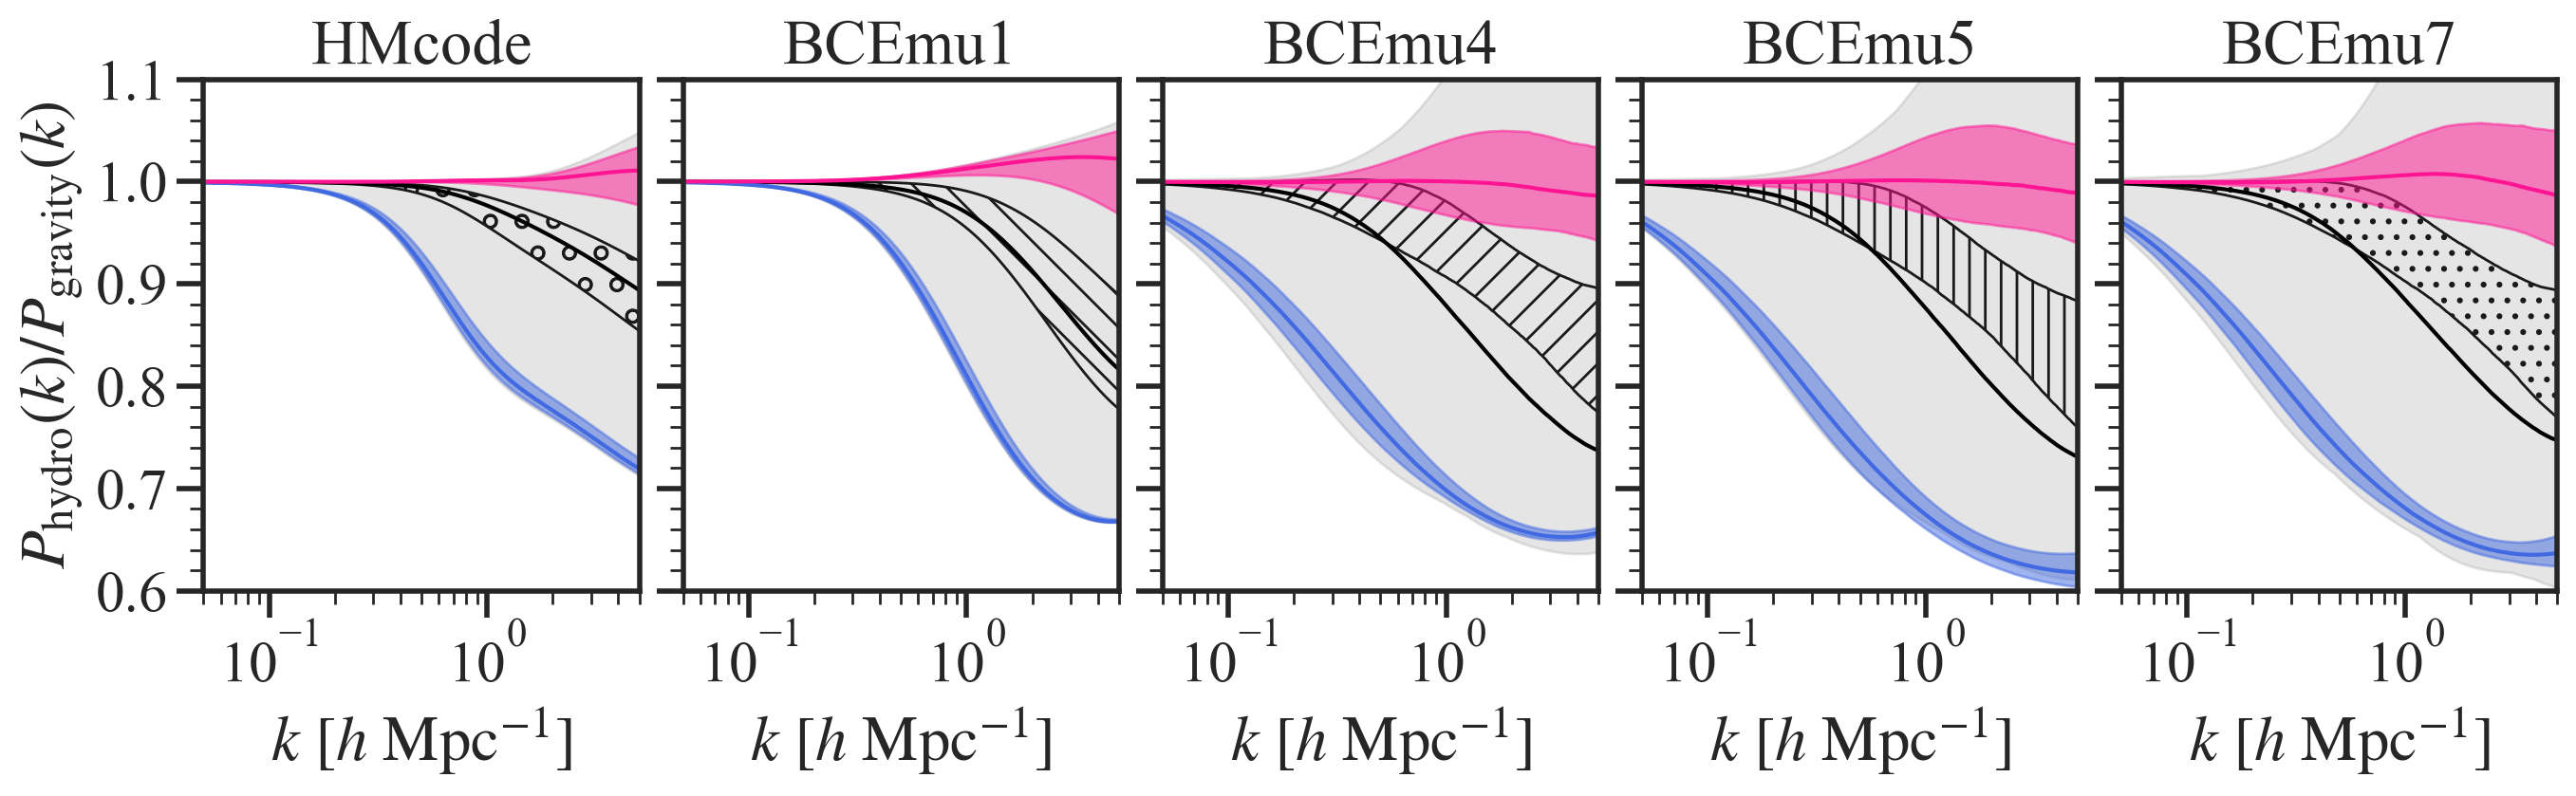

In [4]:
models = ["HMcode", "BCEmu1", "BCEmu4", "BCEmu5", "BCEmu7"]
model_constraints = ["HMcode", "BCEmu1", "BCEmu4", "BCEmu5", "BCEmu7"]

fig, axes = plt.subplots(1, len(model_constraints), figsize=(16, 3.5), sharey=True)
plt.subplots_adjust(wspace=0.1)

colors=['blueviolet', 'royalblue', 'deeppink']
hatchstyles = ["o", "\\\\", "//", "||", ".."]
k_fields = np.geomspace(1e-4, 1e2, 1000)

axes[0].set_ylabel(r'$P_\mathrm{hydro}(k)/P_\mathrm{gravity}(k)$')
for i in range(len(model_constraints)):
    axes[i].set(xlim = [5e-2, 5], ylim=[0.6, 1.1], xscale='log', xlabel=r'$k$ $[h~\mathrm{Mpc}^{-1}]$')
    
    for j in range(1):
        j+=2
        ratio_spk_lo, ratio_spk_med, ratio_spk_hi = np.load('data/frb_results/prior/spk_{}_prior_fullrange_feedbackonly.npy'.format(models[i]))
        if models[i] == "HMcode":
            ratio_spk_lo[(ratio_spk_lo>1) & (k_fields<0.3)] = 1; ratio_spk_med[(ratio_spk_med>1) & (k_fields<0.3)] = 1; ratio_spk_hi[(ratio_spk_hi>1) & (k_fields<0.3)] = 1
        axes[i].fill_between(k_fields/(cosmo.H0.value/100), ratio_spk_lo, ratio_spk_hi, color='gray', alpha=0.2, label="Prior")
        axes[i].plot(k_fields/(cosmo.H0.value/100), ratio_spk_med, color='black')
    
    if models[i] == "BCEmu5" or models[i] == "BCEmu7":
        ratio_spk_lo, ratio_spk_med, ratio_spk_hi = np.load('data/frb_results/spk_{}_extended_Chandraprior.npy'.format(model_constraints[i]))
    else:
        ratio_spk_lo, ratio_spk_med, ratio_spk_hi = np.load('data/frb_results/spk_{}_extended.npy'.format(model_constraints[i]))
    axes[i].fill_between(k_fields/(cosmo.H0.value/100), ratio_spk_lo, ratio_spk_hi, facecolor='none', edgecolor='k', hatch=hatchstyles[i], label='Observed sample')
    axes[i].set_title(model_constraints[i])
    
    if models[i] == "BCEmu5" or models[i] == "BCEmu7":
        ratio_spk_lo, ratio_spk_med, ratio_spk_hi = np.load('data/frb_results/extreme_scenario_test/spk_{}_extended_extremefeedback_Chandraprior.npy'.format(model_constraints[i]))
    else:
        ratio_spk_lo, ratio_spk_med, ratio_spk_hi = np.load('data/frb_results/extreme_scenario_test/spk_{}_extended_extremefeedback.npy'.format(model_constraints[i]))
    if models[i] == "HMcode":
        ratio_spk_lo[(ratio_spk_lo>1) & (k_fields<0.3)] = 1; ratio_spk_med[(ratio_spk_med>1) & (k_fields<0.3)] = 1; ratio_spk_hi[(ratio_spk_hi>1) & (k_fields<0.3)] = 1
    axes[i].fill_between(k_fields/(cosmo.H0.value/100), ratio_spk_lo, ratio_spk_hi, color=colors[1], alpha=0.5, label='Extreme feedback: Mock sample')
    axes[i].plot(k_fields/(cosmo.H0.value/100), ratio_spk_med, color=colors[1])
    
    if models[i] == "BCEmu5" or models[i] == "BCEmu7":
        ratio_spk_lo, ratio_spk_med, ratio_spk_hi = np.load('data/frb_results/extreme_scenario_test/spk_{}_extended_nofeedback_Chandraprior.npy'.format(model_constraints[i]))
    else:
        ratio_spk_lo, ratio_spk_med, ratio_spk_hi = np.load('data/frb_results/extreme_scenario_test/spk_{}_extended_nofeedback.npy'.format(model_constraints[i]))
    if models[i] == "HMcode":
        ratio_spk_lo[(ratio_spk_lo>1) & (k_fields<0.3)] = 1; ratio_spk_med[(ratio_spk_med>1) & (k_fields<0.3)] = 1; ratio_spk_hi[(ratio_spk_hi>1) & (k_fields<0.3)] = 1
    axes[i].fill_between(k_fields/(cosmo.H0.value/100), ratio_spk_lo, ratio_spk_hi, color=colors[2], alpha=0.5, label='No feedback: Mock sample')
    axes[i].plot(k_fields/(cosmo.H0.value/100), ratio_spk_med, color=colors[2])
                         
    axes[i].yaxis.set_major_locator(plt.MultipleLocator(0.1))
    axes[i].yaxis.set_minor_locator(plt.MultipleLocator(0.02))
    
plt.savefig('figures/extreme_scenario_test_spk.pdf', dpi=400, bbox_inches='tight')


In [5]:
def get_samples(mcmc_file):
    class RenameUnpickler(pickle.Unpickler):
        def find_class(self, module, name):
            if module.startswith("numpy._core"):
                module = module.replace("numpy._core", "numpy.core")
            return super().find_class(module, name)
    with open(mcmc_file, "rb") as f:
        results = RenameUnpickler(f).load()
    chain = results["chain"]
    samples = chain.reshape(-1, chain.shape[-1])
    # DMhost transformations
    DMhost_mean = np.exp(samples[:, -2] + ((samples[:, -1]**2)/2))
    DMhost_var = np.sqrt(np.exp(samples[:, -1]**2 - 1) * np.exp(2*samples[:, -2] + samples[:, -1]**2))
    samples[:, -2] = DMhost_mean; samples[:, -1] = DMhost_var
    return samples



In [6]:
cosmo_ccl = ccl.Cosmology(Omega_c = cosmo.Om0-cosmo.Ob0, 
                      Omega_b = cosmo.Ob0, 
                      h = cosmo.H0.value/100, 
                      sigma8 = 0.8111, 
                      n_s = 0.9665, 
                      matter_power_spectrum='linear'
                     )
fb = cosmo_ccl.cosmo.params.Omega_b / cosmo_ccl.cosmo.params.Omega_m

def compute_mass_fraction(Profile, Mass, a = 1, Rfac = 1):
    mdef  = ccl.halos.massdef.MassDef500c
    R500c = mdef.get_radius(cosmo_ccl, Mass, a) / a
    out   = np.zeros_like(Mass) + -99
    for i in range(Mass.size):        
        r = np.geomspace(R500c[i] * 1e-8, R500c[i] * Rfac, 1000)
        m = np.trapz(4 * np.pi * r**2 * Profile.real(cosmo_ccl, r, Mass[i], a), x = r)
        out[i] = m/Mass[i] #Fraction
    return out

c_M_relation = ccl.halos.concentration.ConcentrationIshiyama21


M500c = np.geomspace(1e12, 1e15, 50)


In [7]:
H = cosmo_ccl.cosmo.params.h
MASS_DEF = ccl.halos.massdef.MassDef500c


def compute_schneider_fractions(samples, param_builder, n=100):
    """
    Generic runner for Schneider19 Gas/Stars profiles.
    """
    fgas, fstr = [], []

    for i in tqdm(range(min(n, len(samples)))):
        par = param_builder(samples[i])

        GAS = bfg.Profiles.Schneider19.Gas(
            **par, mass_def=MASS_DEF, c_M_relation=c_M_relation
        )
        STR = bfg.Profiles.Schneider19.Stars(
            **par, mass_def=MASS_DEF, c_M_relation=c_M_relation
        )

        fgas.append(compute_mass_fraction(GAS, M500c))
        fstr.append(compute_mass_fraction(STR, M500c))

    fgas = np.array(fgas)
    fstr = np.array(fstr)

    return fgas, fstr, fgas + fstr


def compute_mead_fractions(samples, n=100):
    """
    Generic runner for Mead20 (HMcode) profiles.
    """
    fgas, fstr = [], []

    for i in tqdm(range(min(n, len(samples)))):
        par = bfg.Profiles.Mead20.Tagn2pars(samples[i], mode="All")

        GAS = bfg.Profiles.Mead20.Gas(
            **par, mass_def=MASS_DEF, c_M_relation=c_M_relation
        )
        STR = bfg.Profiles.Mead20.Stars(
            **par, mass_def=MASS_DEF, c_M_relation=c_M_relation
        )

        fgas.append(compute_mass_fraction(GAS, M500c))
        fstr.append(compute_mass_fraction(STR, M500c))

    fgas = np.array(fgas)
    fstr = np.array(fstr)

    return fgas, fstr, fgas + fstr


# ============================================================
# Parameter Builders (Schneider)
# ============================================================

def base_schneider_dict():
    return dict(
        theta_co=0.1,
        tau=-1.5,
        tau_delta=0,
        A=0.055 / 2,
        M1=2.5e11 / H,
        epsilon_h=0.015,
        a=0.3,
        n=2,
        epsilon=4,
        p=0.3,
        q=0.707,
    )


def builder_BCEmu7(x):
    base = base_schneider_dict()
    base.update(
        theta_ej=x[1],
        M_c=(10**x[0]) / H,
        mu_beta=x[2],
        delta=x[3],
        eta=x[4],
        eta_delta=x[5],
        gamma=x[6],
    )
    return base


def builder_BCEmu5(x):
    base = base_schneider_dict()
    base.update(
        theta_ej=x[1],
        M_c=(10**x[0]) / H,
        mu_beta=x[2],
        delta=x[3],
        eta=x[4],
        eta_delta=0.2,
        gamma=2.5,
    )
    return base


def builder_BCEmu4(x):
    base = base_schneider_dict()
    base.update(
        theta_ej=x[1],
        M_c=(10**x[0]) / H,
        mu_beta=x[2],
        delta=x[3],
        eta=0.2,
        eta_delta=0.2,
        gamma=2.5,
    )
    return base


def builder_BCEmu1(x):
    base = base_schneider_dict()
    base.update(
        theta_ej=3.5,
        M_c=(10**x[0]) / H,
        mu_beta=1,
        delta=7,
        eta=0.2,
        eta_delta=0.2,
        gamma=2.5,
    )
    return base


# ============================================================
# Sample Loaders
# ============================================================

def load_prior_samples(cols):
    df = pd.read_csv(
        "../DMvar_SPk_emulators/BCEmu7_high_z_BFGupdate/param_grid_LH.csv"
    ).head(100)
    return np.array([df[c] for c in cols]).T


def load_emcee_samples(path, cols=None):
    samples = get_samples(path)
    if cols is not None:
        samples = samples[:, cols]
    return samples[:100]




In [8]:
# -------------------------
# PRIOR
# -------------------------
BCEmu7_prior = load_prior_samples(
    ["logMc", "theta_ej", "mu_beta", "delta", "eta", "eta_delta", "gamma"]
)

fgas_BCEmu7_prior, fstr_BCEmu7_prior, fbaryon_BCEmu7_prior = \
    compute_schneider_fractions(BCEmu7_prior, builder_BCEmu7)

BCEmu5_prior = load_prior_samples(
    ["logMc", "theta_ej", "mu_beta", "delta", "eta"]
)

fgas_BCEmu5_prior, fstr_BCEmu5_prior, fbaryon_BCEmu5_prior = \
    compute_schneider_fractions(BCEmu5_prior, builder_BCEmu5)

BCEmu4_prior = load_prior_samples(
    ["logMc", "theta_ej", "mu_beta", "delta"]
)

fgas_BCEmu4_prior, fstr_BCEmu4_prior, fbaryon_BCEmu4_prior = \
    compute_schneider_fractions(BCEmu4_prior, builder_BCEmu4)

BCEmu1_prior = load_prior_samples(["logMc"])

fgas_BCEmu1_prior, fstr_BCEmu1_prior, fbaryon_BCEmu1_prior = \
    compute_schneider_fractions(BCEmu1_prior, builder_BCEmu1)

HMcode_prior = np.array(
    pd.read_csv(
        "../DMvar_SPk_emulators/HMcode/neural_network_emulator-5e4_samples/param_grid_HMcode_LH5e4.csv"
    ).head(100).Tagn
)

fgas_HMcode_prior, fstr_HMcode_prior, fbaryon_HMcode_prior = \
    compute_mead_fractions(HMcode_prior)



# -------------------------
# DEFAULT POSTERIOR
# -------------------------
BCEmu7_default = load_emcee_samples(
    "data/frb_results/emcee_BCEmu7_extended_Chandraprior.pkl",
    cols=[0, 1, 3, 5, 6, 2, 4]
)

fgas_BCEmu7, fstr_BCEmu7, fbaryon_BCEmu7 = \
    compute_schneider_fractions(BCEmu7_default, builder_BCEmu7)

BCEmu5_default = load_emcee_samples(
    "data/frb_results/emcee_BCEmu5_extended_Chandraprior.pkl"
)

fgas_BCEmu5, fstr_BCEmu5, fbaryon_BCEmu5 = \
    compute_schneider_fractions(BCEmu5_default, builder_BCEmu5)

BCEmu4_default = load_emcee_samples("data/frb_results/emcee_BCEmu4_extended.pkl")

fgas_BCEmu4, fstr_BCEmu4, fbaryon_BCEmu4 = \
    compute_schneider_fractions(BCEmu4_default, builder_BCEmu4)



# -------------------------
# NO FEEDBACK
# -------------------------
BCEmu7_nofeedback = load_emcee_samples(
    "data/frb_results/extreme_scenario_test/"
    "emcee_BCEmu7_extended_nofeedback_Chandraprior.pkl",
    cols=[0, 1, 3, 5, 6, 2, 4]
)

fgas_BCEmu7_nofeedback, fstr_BCEmu7_nofeedback, fbaryon_BCEmu7_nofeedback = \
    compute_schneider_fractions(BCEmu7_nofeedback, builder_BCEmu7)

BCEmu5_nofeedback = load_emcee_samples(
    "data/frb_results/extreme_scenario_test/"
    "emcee_BCEmu5_extended_nofeedback_Chandraprior.pkl"
)

fgas_BCEmu5_nofeedback, fstr_BCEmu5_nofeedback, fbaryon_BCEmu5_nofeedback = \
    compute_schneider_fractions(BCEmu5_nofeedback, builder_BCEmu5)

BCEmu4_nofeedback = load_emcee_samples(
    "data/frb_results/extreme_scenario_test/emcee_BCEmu4_extended_nofeedback.pkl"
)

fgas_BCEmu4_nofeedback, fstr_BCEmu4_nofeedback, fbaryon_BCEmu4_nofeedback = \
    compute_schneider_fractions(BCEmu4_nofeedback, builder_BCEmu4)



# -------------------------
# EXTREME FEEDBACK
# -------------------------
BCEmu7_extreme = load_emcee_samples(
    "data/frb_results/extreme_scenario_test/"
    "emcee_BCEmu7_extended_extremefeedback_Chandraprior.pkl",
    cols=[0, 1, 3, 5, 6, 2, 4]
)

fgas_BCEmu7_extremefeedback, fstr_BCEmu7_extremefeedback, fbaryon_BCEmu7_extremefeedback = \
    compute_schneider_fractions(BCEmu7_extreme, builder_BCEmu7)

BCEmu5_extreme = load_emcee_samples(
    "data/frb_results/extreme_scenario_test/"
    "emcee_BCEmu5_extended_extremefeedback_Chandraprior.pkl"
)

fgas_BCEmu5_extremefeedback, fstr_BCEmu5_extremefeedback, fbaryon_BCEmu5_extremefeedback = \
    compute_schneider_fractions(BCEmu5_extreme, builder_BCEmu5)

BCEmu4_extreme = load_emcee_samples(
    "data/frb_results/extreme_scenario_test/emcee_BCEmu4_extended_extremefeedback.pkl"
)

fgas_BCEmu4_extremefeedback, fstr_BCEmu4_extremefeedback, fbaryon_BCEmu4_extremefeedback = \
    compute_schneider_fractions(BCEmu4_extreme, builder_BCEmu4)



BCEmu1_default = load_emcee_samples("data/frb_results/emcee_BCEmu1_extended.pkl")
BCEmu1_nofeedback = load_emcee_samples(
    "data/frb_results/extreme_scenario_test/emcee_BCEmu1_extended_nofeedback.pkl"
)
BCEmu1_extreme = load_emcee_samples(
    "data/frb_results/extreme_scenario_test/emcee_BCEmu1_extended_extremefeedback.pkl"
)

fgas_BCEmu1, fstr_BCEmu1, fbaryon_BCEmu1 = \
    compute_schneider_fractions(BCEmu1_default, builder_BCEmu1)

fgas_BCEmu1_nofeedback, fstr_BCEmu1_nofeedback, fbaryon_BCEmu1_nofeedback = \
    compute_schneider_fractions(BCEmu1_nofeedback, builder_BCEmu1)

fgas_BCEmu1_extremefeedback, fstr_BCEmu1_extremefeedback, fbaryon_BCEmu1_extremefeedback = \
    compute_schneider_fractions(BCEmu1_extreme, builder_BCEmu1)

HMcode_default = load_emcee_samples("data/frb_results/emcee_HMcode_extended.pkl")
HMcode_nofeedback = load_emcee_samples(
    "data/frb_results/extreme_scenario_test/emcee_HMcode_extended_nofeedback.pkl"
)
HMcode_extreme = load_emcee_samples(
    "data/frb_results/extreme_scenario_test/emcee_HMcode_extended_extremefeedback.pkl"
)

fgas_HMcode, fstr_HMcode, fbaryon_HMcode = \
    compute_mead_fractions(HMcode_default[:, 0])

fgas_HMcode_nofeedback, fstr_HMcode_nofeedback, fbaryon_HMcode_nofeedback = \
    compute_mead_fractions(HMcode_nofeedback[:, 0])

fgas_HMcode_extremefeedback, fstr_HMcode_extremefeedback, fbaryon_HMcode_extremefeedback = \
    compute_mead_fractions(HMcode_extreme[:, 0])



100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 20.81it/s]


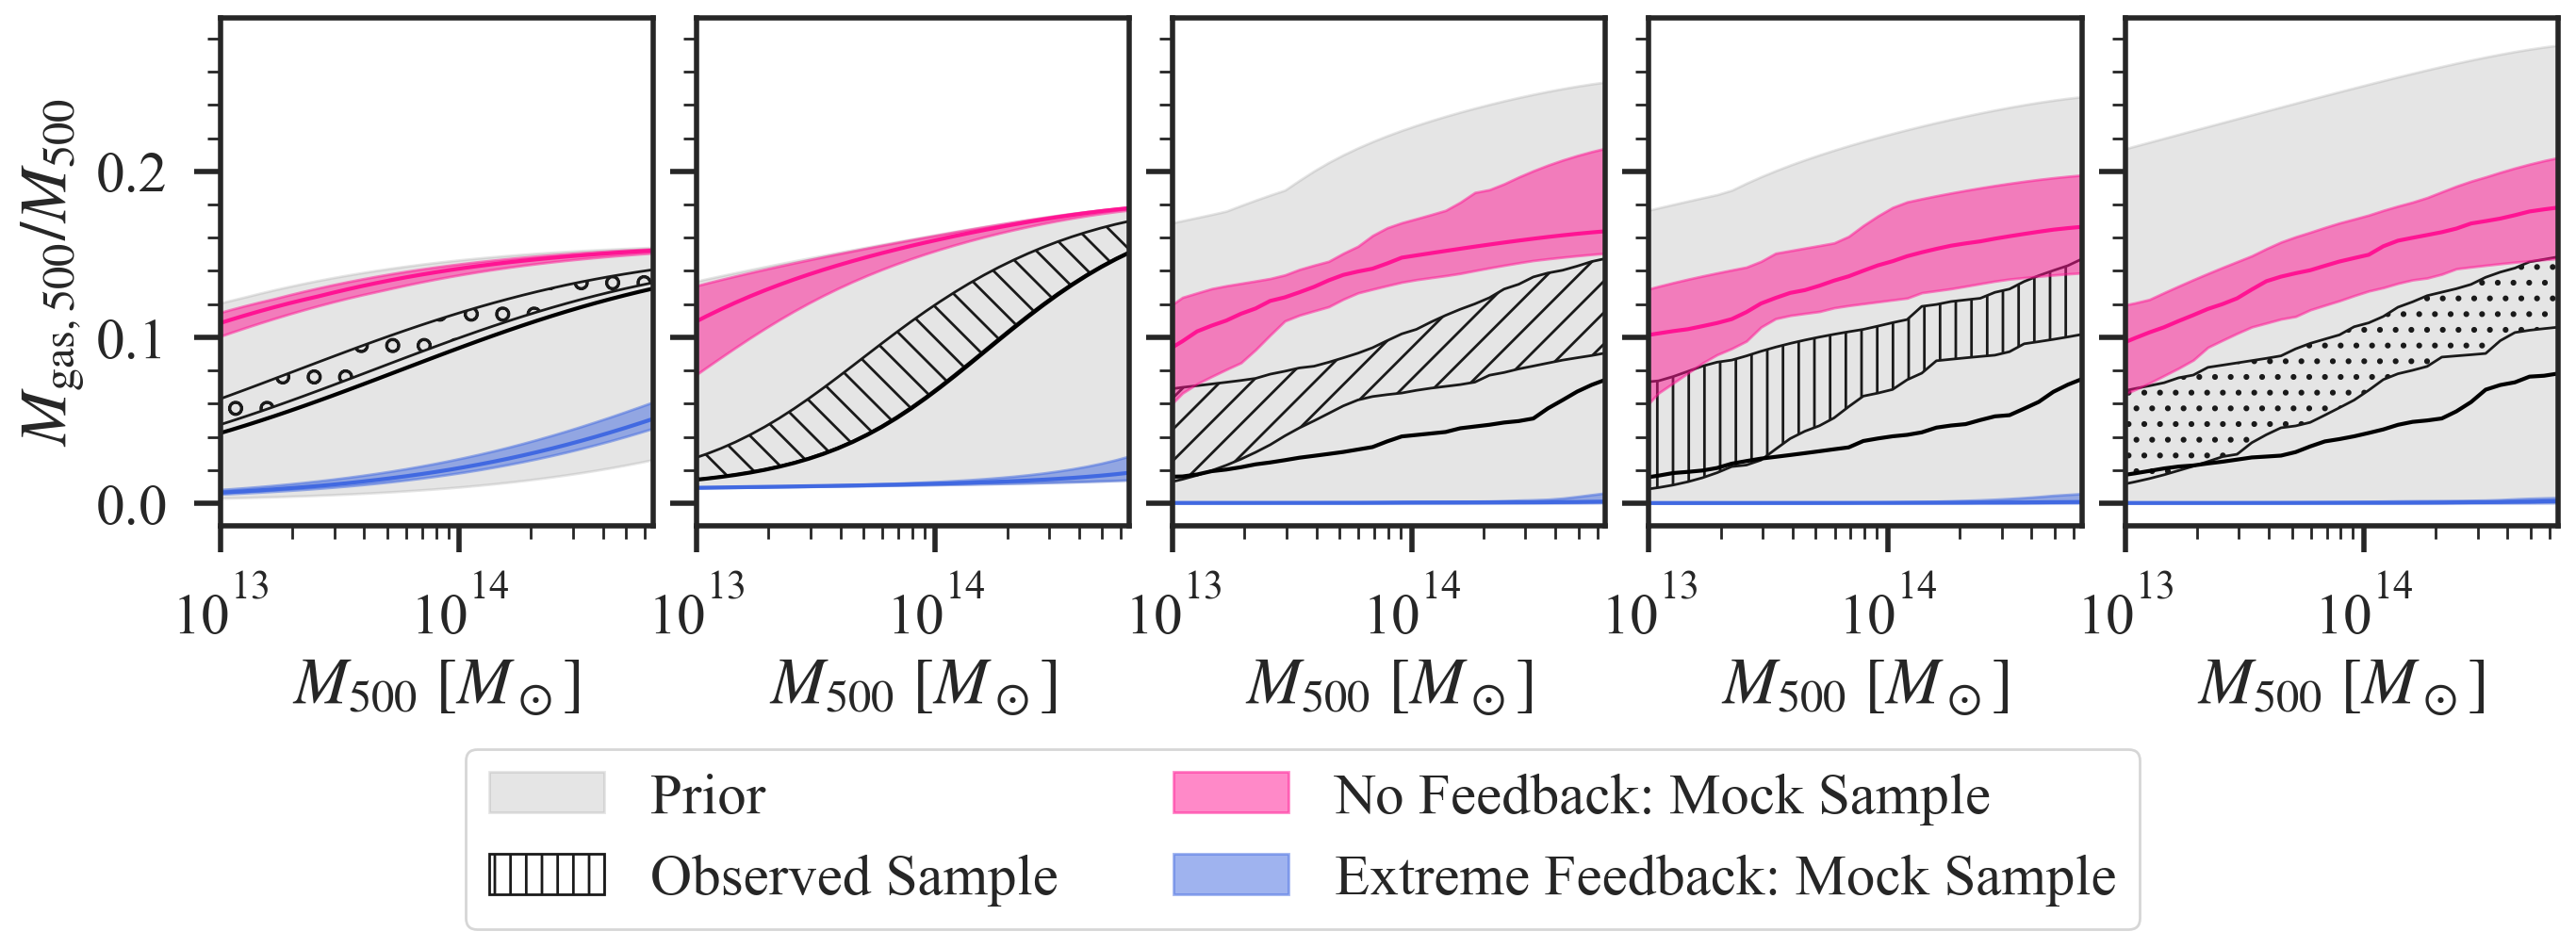

In [9]:
def plot_fgas_panel(ax, M500c, prior, default, nofb, extreme,
                    hatch=None, show_legend=False):

    # --- PRIOR (full range)
    ax.fill_between(
        M500c,
        np.percentile(prior, 0, axis=0),
        np.percentile(prior, 100, axis=0),
        color="gray", alpha=0.2,
        label="Prior" if show_legend else None
    )
    ax.plot(
        M500c,
        np.percentile(prior, 50, axis=0),
        color="black"
    )

    # --- DEFAULT (hatched)
    ax.fill_between(
        M500c,
        np.percentile(default, 16, axis=0),
        np.percentile(default, 84, axis=0),
        facecolor='none',
        edgecolor='k',
        hatch=hatch,
        label="Observed Sample" if show_legend else None
    )

    # --- NO FEEDBACK
    ax.fill_between(
        M500c,
        np.percentile(nofb, 16, axis=0),
        np.percentile(nofb, 84, axis=0),
        color=colors[2],
        alpha=0.5,
        label="No Feedback: Mock Sample" if show_legend else None
    )
    ax.plot(
        M500c,
        np.percentile(nofb, 50, axis=0),
        color=colors[2]
    )

    # --- EXTREME FEEDBACK
    ax.fill_between(
        M500c,
        np.percentile(extreme, 16, axis=0),
        np.percentile(extreme, 84, axis=0),
        color=colors[0],
        alpha=0.5,
        label="Extreme Feedback: Mock Sample" if show_legend else None
    )
    ax.plot(
        M500c,
        np.percentile(extreme, 50, axis=0),
        color=colors[0]
    )
    
    
fig, axes = plt.subplots(
    1, len(model_constraints),
    figsize=(16, 3.5),
    sharey=True
)
plt.subplots_adjust(wspace=0.1)

colors = ['royalblue', 'blueviolet', 'deeppink']

model_data = [
    (fgas_HMcode_prior,  fgas_HMcode,  fgas_HMcode_nofeedback,  fgas_HMcode_extremefeedback),
    (fgas_BCEmu1_prior,  fgas_BCEmu1,  fgas_BCEmu1_nofeedback,  fgas_BCEmu1_extremefeedback),
    (fgas_BCEmu4_prior,  fgas_BCEmu4,  fgas_BCEmu4_nofeedback,  fgas_BCEmu4_extremefeedback),
    (fgas_BCEmu5_prior,  fgas_BCEmu5,  fgas_BCEmu5_nofeedback,  fgas_BCEmu5_extremefeedback),
    (fgas_BCEmu7_prior,  fgas_BCEmu7,  fgas_BCEmu7_nofeedback,  fgas_BCEmu7_extremefeedback),
]

for i, ax in enumerate(axes):
    prior, default, nofb, extreme = model_data[i]

    plot_fgas_panel(
        ax,
        M500c,
        prior,
        default,
        nofb,
        extreme,
        hatch=hatchstyles[i],
        show_legend=(i == 3)
    )

    ax.set_xlim(1e13, 6.5e14)
    ax.set_xscale('log')
    ax.set_xlabel(r'$M_{500}~[M_\odot]$', size=25)
    ax.tick_params(pad=10)
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.02))

axes[0].set_ylabel(r'$M_\mathrm{gas,500}/M_\mathrm{500}$', size=25)

axes[3].legend(
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(-0.8, -0.85)
)

plt.savefig(
    'figures/extreme_scenario_test_fgas.pdf',
    dpi=400,
    bbox_inches='tight'
)


In [10]:
from scipy.stats import entropy

def kl_divergence_from_samples(p_samples, q_samples, method='kde', num_bins=100):
    """
    Compute KL divergence D_KL(p||q) numerically from samples.
    Returns D (KL divergence), Dexp (expected KL), S (surprise) in bits.
    """
    # Build PDFs
    if method == 'hist':
        # Use histograms
        hist_range = (min(p_samples.min(), q_samples.min()), max(p_samples.max(), q_samples.max()))
        p_hist, bins = np.histogram(p_samples, bins=num_bins, range=hist_range, density=True)
        q_hist, _ = np.histogram(q_samples, bins=bins, density=True)
        # Avoid zeros
        p_hist += 1e-12
        q_hist += 1e-12
        D = entropy(p_hist, q_hist, base=2)  # KL divergence in bits
        # Expected KL (entropy of p relative to itself)
        Dexp = entropy(p_hist, p_hist, base=2)
    elif method == 'kde':
        # Use KDE to get smooth PDFs
        p_kde = gaussian_kde(p_samples)
        q_kde = gaussian_kde(q_samples)
        x = np.linspace(min(p_samples.min(), q_samples.min()), 
                        max(p_samples.max(), q_samples.max()), 1000)
        p_vals = p_kde(x) + 1e-12
        q_vals = q_kde(x) + 1e-12
        D = entropy(p_vals, q_vals, base=2)
        Dexp = entropy(p_vals, p_vals, base=2)
    else:
        raise ValueError("method must be 'hist' or 'kde'")
    
    S = D - Dexp
    return D, Dexp, S

prior_samples = np.load('data/frb_results/prior/spk_BCEmu5_prior_samples_feedbackonly.npy')
posterior_samples = np.load('data/frb_results/spk_BCEmu5_posterior_samples_feedbackonly_extended_Chandraprior.npy')
posterior_samples_nofeedback = np.load('data/frb_results/extreme_scenario_test/spk_BCEmu5_posterior_samples_feedbackonly_extended_nofeedback_Chandraprior.npy')
posterior_samples_extremefeedback = np.load('data/frb_results/extreme_scenario_test/spk_BCEmu5_posterior_samples_feedbackonly_extended_extremefeedback_Chandraprior.npy')

from joblib import Parallel, delayed
def compute_divergence(i, k):
    D, Dexp, S = kl_divergence_from_samples(prior_samples[:, i], posterior_samples[:, i], method='hist')
    return D, Dexp, S
results = Parallel(n_jobs=-1, backend='loky')(
    delayed(compute_divergence)(i, k) for i, k in enumerate(k_fields)
)
D_k, Dexp_k, S_k = map(list, zip(*results))

def compute_divergence(i):
    D, Dexp, S = kl_divergence_from_samples(prior_samples[:, i], posterior_samples_nofeedback[:, i], method='hist')
    return D, Dexp, S
results = Parallel(n_jobs=-1, backend='loky')(
    delayed(compute_divergence)(i) for i in tqdm(range(len(k_fields)))
)
D_k_nofeedback, Dexp_k_nofeedback, S_k_nofeedback = map(list, zip(*results))

def compute_divergence(i):
    D, Dexp, S = kl_divergence_from_samples(prior_samples[:, i], posterior_samples_extremefeedback[:, i], method='hist')
    return D, Dexp, S
results = Parallel(n_jobs=-1, backend='loky')(
    delayed(compute_divergence)(i) for i in tqdm(range(len(k_fields)))
)
D_k_extremefeedback, Dexp_k_extremefeedback, S_k_extremefeedback = map(list, zip(*results))


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:33<00:00, 29.60it/s]


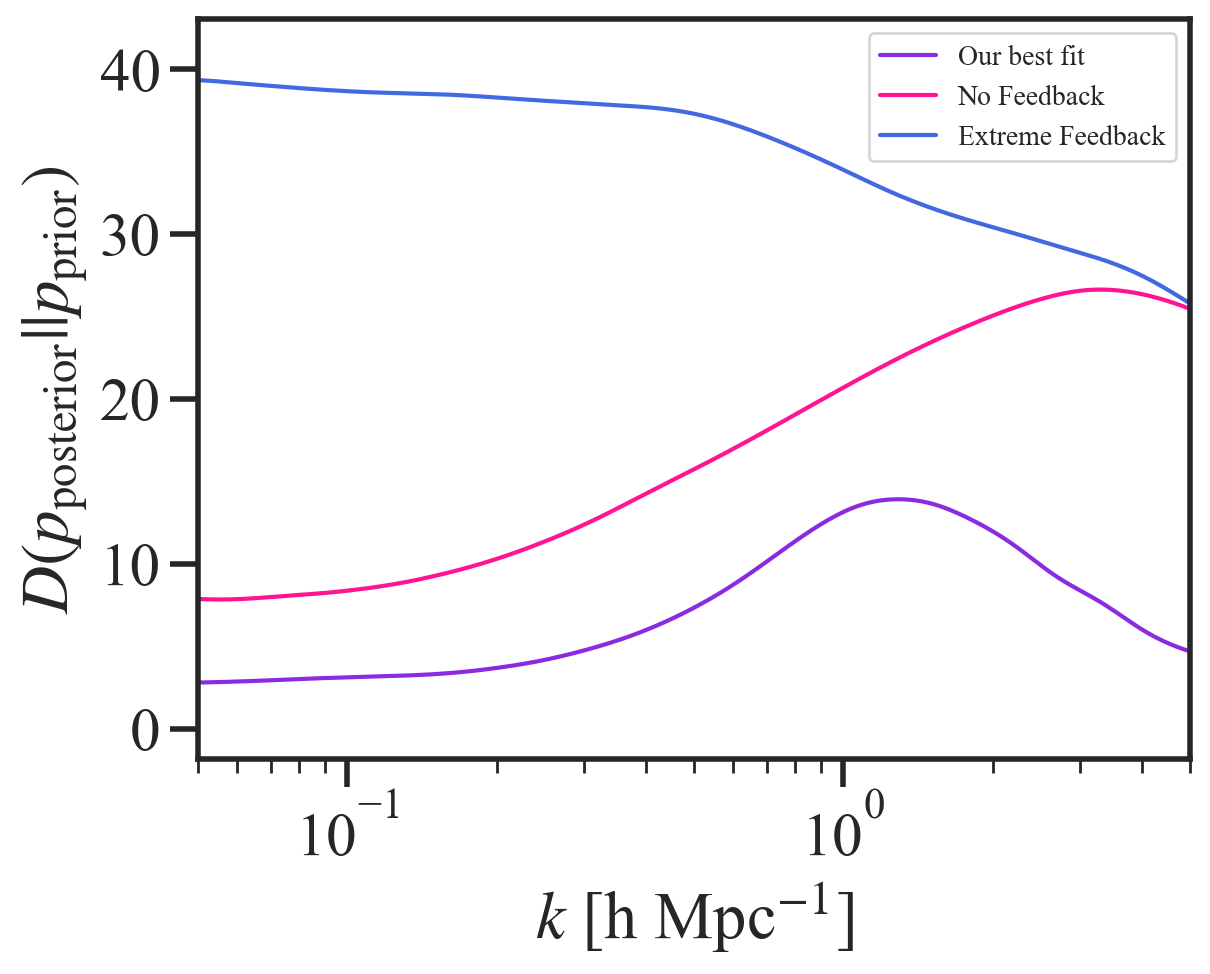

In [11]:
from scipy.ndimage import gaussian_filter
plt.plot(k_fields/(cosmo.H0.value/100), gaussian_filter(S_k, 10), label='Our best fit', color="blueviolet")
plt.plot(k_fields/(cosmo.H0.value/100), gaussian_filter(S_k_nofeedback, 10), label='No Feedback', color="deeppink")
plt.plot(k_fields/(cosmo.H0.value/100), gaussian_filter(S_k_extremefeedback, 10), label='Extreme Feedback', color="royalblue")
plt.xlabel(r'$k$ [h Mpc$^{-1}$]')
plt.ylabel(r'$D(p_\mathrm{posterior} || p_\mathrm{prior})$')
plt.xscale('log')
plt.xlim(5e-2, 5)
plt.legend(fontsize=10)


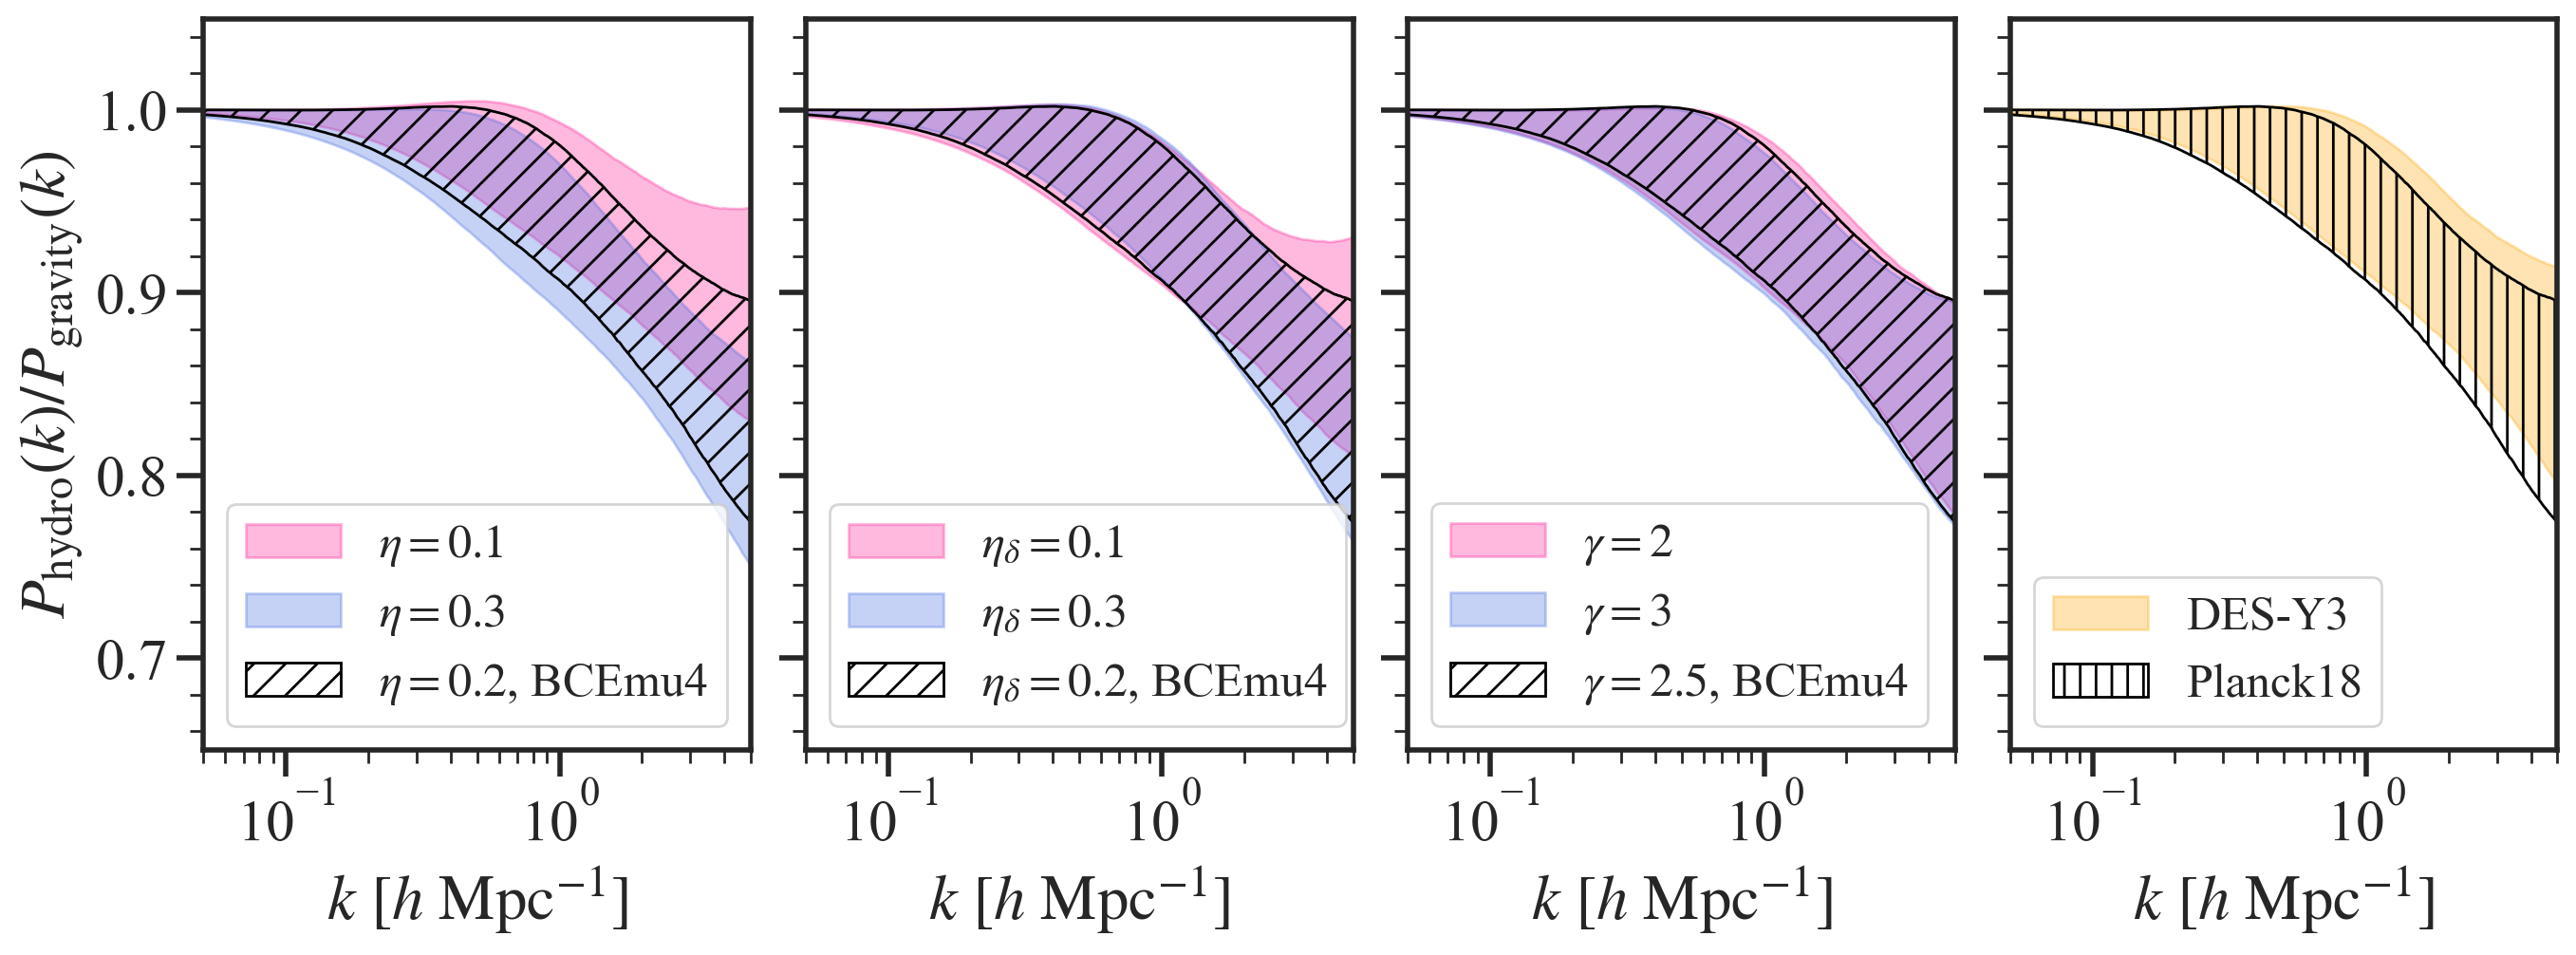

In [12]:
panel_labels = ['eta', 'eta_delta', 'gamma']
fig, axes = plt.subplots(1, len(panel_labels)+1, figsize=(4*(len(panel_labels)+1), 5), sharey=True)
plt.subplots_adjust(wspace=0.1)

k_fields = np.geomspace(1e-4, 1e2, 1000)

ratio_ref_lo, ratio_ref_med, ratio_ref_hi = np.load(
    'data/frb_results/spk_BCEmu4_extended.npy'
)

# Define all variations
variations = {
    'eta': ['eta_low', 'eta_high'],
    'eta_delta': ['eta_delta_low', 'eta_delta_high'],
    'gamma': ['gamma_low', 'gamma_high'],
}

labels = {
    'eta': [r'$\eta=0.1$', r'$\eta=0.3$'],
    'eta_delta': [r'$\eta_\delta=0.1$', r'$\eta_\delta=0.3$'],
    'gamma': [r'$\gamma=2$', r'$\gamma=3$'],
}

labels_ref = {
    'eta': r'$\eta=0.2$, BCEmu4',
    'eta_delta': r'$\eta_\delta=0.2$, BCEmu4',
    'gamma': r'$\gamma=2.5$, BCEmu4',
}

# Color map for variation shading
colors = ['deeppink', 'royalblue']

for ax, param in zip(axes, panel_labels):
    ax.set(xscale='log', xlabel=r'$k$ $[h~\mathrm{Mpc}^{-1}]$')
    ax.set_xlim([5e-2, 5])
    ax.set_ylim([0.65, 1.05])

    # Plot each variation
    for i, label in enumerate(variations[param]):
        ratio_lo, ratio_med, ratio_hi = np.load(
            f'data/frb_results/vary_feedback_params_cosmology/spk_BCEmu4_extended_vary_{label}.npy'
        )
        label = labels[param][i]
        ax.fill_between(k_fields/(cosmo.H0.value/100), ratio_lo, ratio_hi, color=colors[i], alpha=0.3, label=label)

    # Plot the black reference curve on all panels
    ax.fill_between(k_fields/(cosmo.H0.value/100), ratio_ref_lo, ratio_ref_hi, facecolor='none', edgecolor='black', hatch='//', alpha=1, label=labels_ref[param])
    ax.legend(loc="lower left", fontsize=18)
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.02))
    
axes[3].set(xscale='log', xlabel=r'$k$ $[h~\mathrm{Mpc}^{-1}]$', xlim=[5e-2, 5], ylim=[0.65, 1.05])
ratio_lo, ratio_med, ratio_hi = np.load(
    f'data/frb_results/vary_feedback_params_cosmology/spk_BCEmu5_extended_DEScosmology_Chandraprior.npy'
)
axes[3].fill_between(k_fields/(cosmo.H0.value/100), ratio_lo, ratio_hi, color="orange", alpha=0.3, label="DES-Y3")
axes[3].fill_between(k_fields/(cosmo.H0.value/100), ratio_ref_lo, ratio_ref_hi, facecolor='none', edgecolor='black', hatch='||', alpha=1, label="Planck18")
axes[3].legend(loc="lower left", fontsize=18)
axes[3].yaxis.set_major_locator(plt.MultipleLocator(0.1))
axes[3].yaxis.set_minor_locator(plt.MultipleLocator(0.02))


axes[0].set_ylabel(r'$P_\mathrm{hydro}(k)/P_\mathrm{gravity}(k)$')

plt.savefig('figures/spk_vary_feedback_cosmology.pdf', dpi=400, bbox_inches='tight')



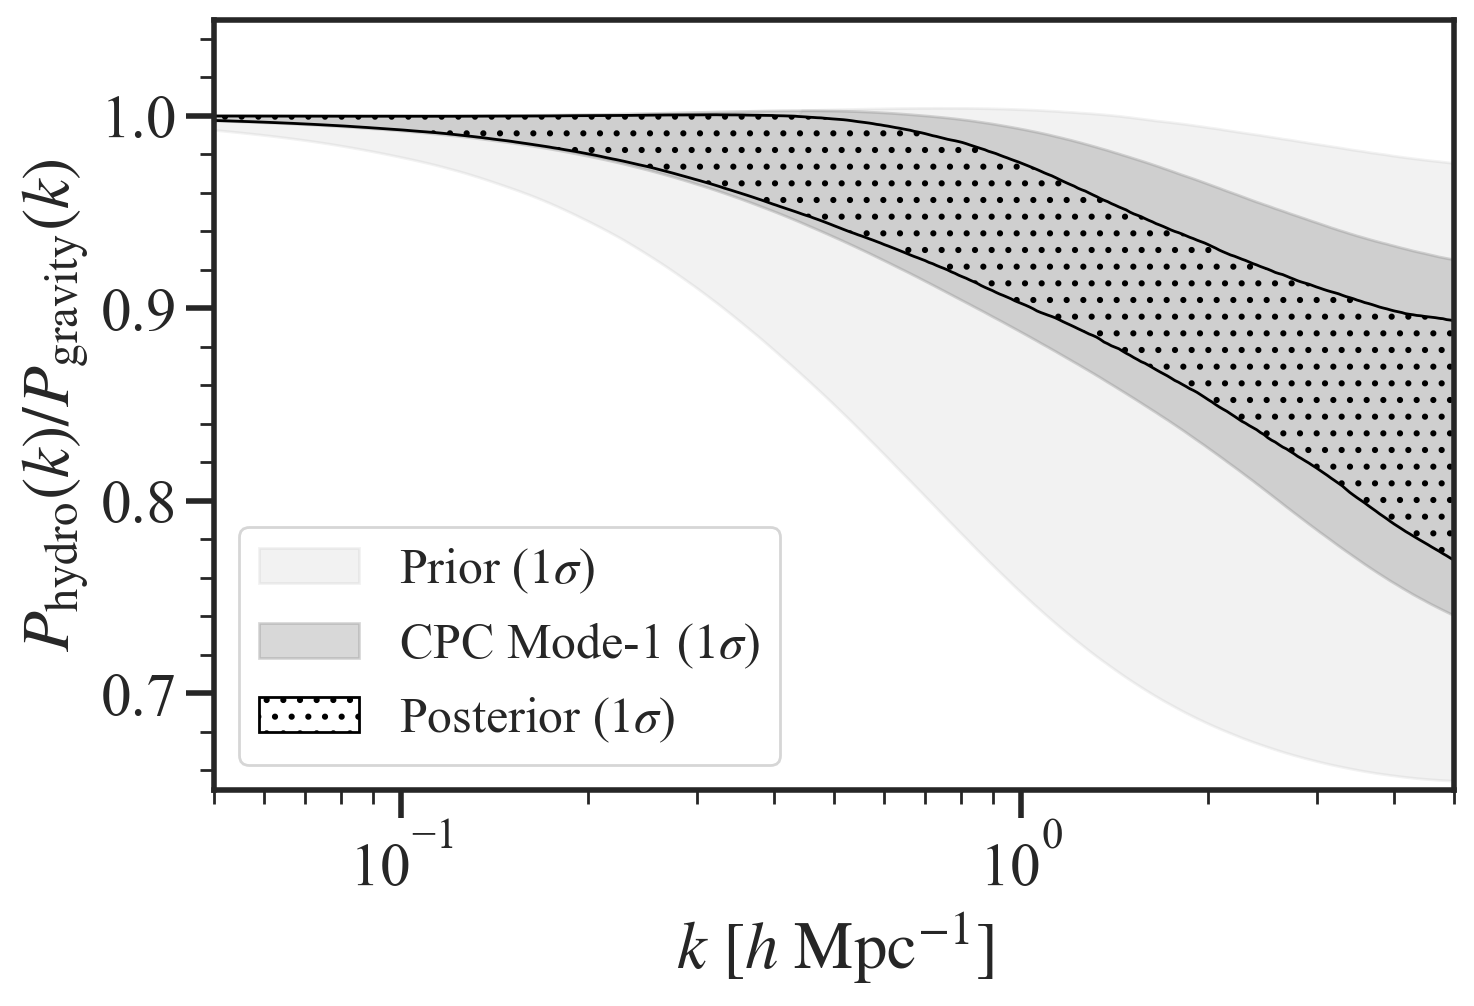

In [13]:
model_constraints = ["BCEmu7"]

fig, axes = plt.subplots(1, len(model_constraints), figsize=(8, 5), sharey=True)
plt.subplots_adjust(wspace=0.1)
axes = [axes]

k_fields = np.geomspace(1e-4, 1e2, 1000)

axes[0].set_ylabel(r'$P_\mathrm{hydro}(k)/P_\mathrm{gravity}(k)$')
for i in range(len(model_constraints)):
    axes[i].set(xlim = [5e-2, 5], ylim=[0.65, 1.05], xscale='log', xlabel=r'$k$ $[h~\mathrm{Mpc}^{-1}]$')
    
    for j in range(1):
        j+=2
        ratio_spk_lo, ratio_spk_med, ratio_spk_hi = np.load('data/frb_results/spk_BCEmu7_prior_1sigma_vary_all.npy')
        if models[i] == "HMcode":
            ratio_spk_lo[(ratio_spk_lo>1) & (k_fields<0.3)] = 1; ratio_spk_med[(ratio_spk_med>1) & (k_fields<0.3)] = 1; ratio_spk_hi[(ratio_spk_hi>1) & (k_fields<0.3)] = 1
        axes[i].fill_between(k_fields/(cosmo.H0.value/100), ratio_spk_lo, ratio_spk_hi, color='gray', alpha=0.1, label="Prior ($1\sigma$)")
         
        ratio_spk_lo, ratio_spk_med, ratio_spk_hi = np.load('data/frb_results/spk_BCEmu7_prior_1sigma_vary_all_but_logMc_thetaej_mubeta_delta.npy')
        axes[i].fill_between(k_fields/(cosmo.H0.value/100), ratio_spk_lo, ratio_spk_hi, color='gray', alpha=0.3, label=r"CPC Mode-1 ($1\sigma$)")
        
    ratio_spk_lo, ratio_spk_med, ratio_spk_hi = np.load('data/frb_results/spk_BCEmu7_extended_Chandraprior.npy')
    axes[i].fill_between(k_fields/(cosmo.H0.value/100), ratio_spk_lo, ratio_spk_hi, facecolor='none', edgecolor='black', hatch='..', label="Posterior ($1\sigma$)")
    axes[i].yaxis.set_major_locator(plt.MultipleLocator(0.1))
    axes[i].yaxis.set_minor_locator(plt.MultipleLocator(0.02))
    
axes[0].legend(fontsize=18)

plt.savefig('figures/spk_BCEmu7_CPC.pdf', dpi=400, bbox_inches='tight')
